In [5]:
import ccdproc as ccdp
from astropy.io import fits
import os
from pathlib import Path
import numpy as np
from astropy.stats import mad_std
from convenience_functions import show_image
from astropy.nddata import CCDData
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm


In [12]:
path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')
combined_path = path / 'combined'
combined_dark_name = 'master_dark.fits'
combined_bias_name = 'master_bias6frames_high_2025_05_15.fits'


In [14]:
print("Checking for existing combined bias file...")

combined_bias_file = combined_path / combined_bias_name

if combined_bias_file.exists():
    print("Found existing combined bias file. Reading it...")
    combined_bias = CCDData.read(combined_bias_file) 

else:
    print("No existing bias. Starting combination...")

    main_path = ccdp.ImageFileCollection(path)
    all_bias = main_path.files_filtered(OBSTYPE='BIAS', include_path=True)

    print(f"Found {len(all_bias)} bias files. Combining now...")

    combined_bias = ccdp.combine(
        all_bias,
        method='median',
        sigma_clip=True,
        sigma_clip_low_thresh=5,
        sigma_clip_high_thresh=5,
        sigma_clip_func=np.ma.median,
        sigma_clip_dev_func=mad_std,
        mem_limit=350e6
    )

    combined_bias.meta['comb-med'] = True

    combined_bias.write(combined_path / combined_bias_name, overwrite=True)
    print("Bias combination completed and saved.")



Checking for existing combined bias file...
Found existing combined bias file. Reading it...


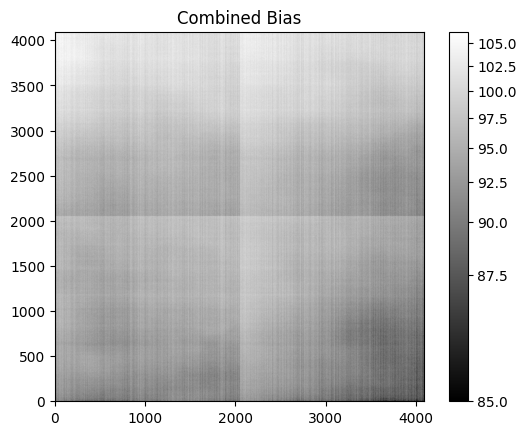

In [15]:

plt.figure()
norm = simple_norm(combined_bias.data, 'sqrt', percent=99)
plt.imshow(combined_bias.data, cmap='gray', origin='lower', norm=norm)
plt.title('Combined Bias')
plt.colorbar()
#plt.savefig('combined_bias.png', dpi=150, bbox_inches='tight')
#print("Done. Image saved.")
plt.show()

plt.close()



INFO:astropy:splitting each image into 58 chunks to limit memory usage to 350000000.0 bytes.


INFO: splitting each image into 58 chunks to limit memory usage to 350000000.0 bytes. [ccdproc.combiner]


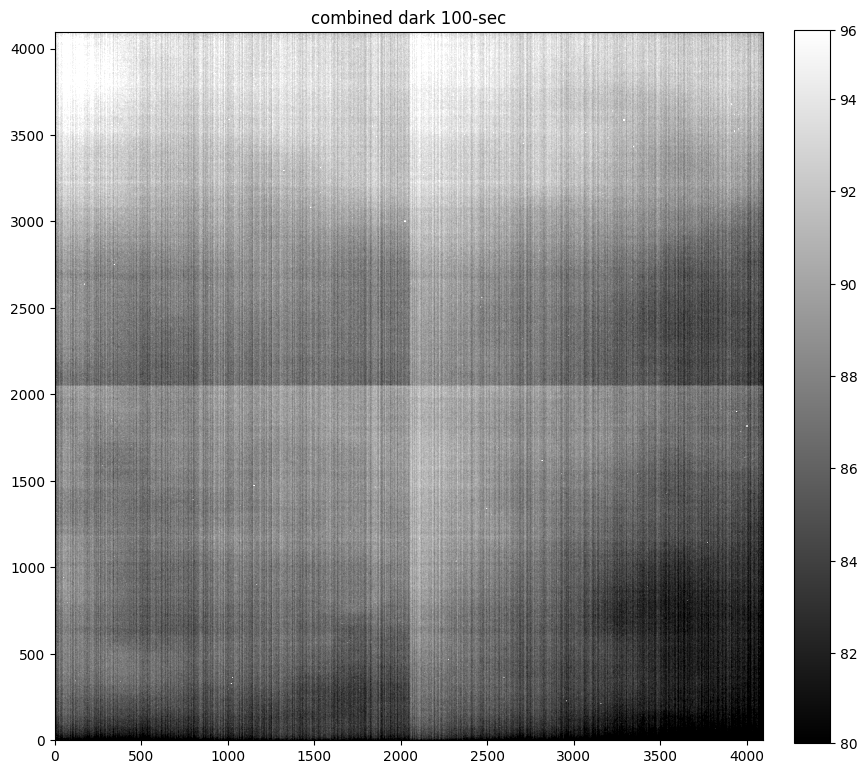

In [17]:
## STEP 2. Master Dark
## NOTE! Darks should have exposure times closest to light. Never scale darks up in time for it would add noise!

# Check if combined dark file exists
combined_dark_file = combined_path / combined_dark_name
#if combined_dark_file.exists():
#    # Read the existing combined dark file as a CCDData object
#    combined_dark = CCDData.read(combined_dark_file) 

#else:
    # Perform the combination if the file doesn't exist
main_path = ccdp.ImageFileCollection(path)  # Assuming 'path' is defined somewhere

    # Performing the actual combination of the bias images and performing sigmaclipping as well.
all_darks = main_path.files_filtered(OBSTYPE='DARK', include_path=True)  # Get all DARK files

combined_dark = ccdp.combine(all_darks,
                                 method='median',
                                 sigma_clip=True, sigma_clip_low_thresh=5, sigma_clip_high_thresh=5,
                                 sigma_clip_func=np.ma.median, sigma_clip_dev_func=mad_std,
                                 mem_limit=350e6
                                 )

combined_dark.meta['comb-med'] = True

combined_dark.write(combined_path / combined_dark_name, overwrite=True)
    
show_image(combined_dark, cmap='gray')
plt.title('combined dark 100-sec')
plt.savefig('combined_dark.png', dpi=300, bbox_inches='tight')
plt.show() 

In [8]:
# Define the conversion factor from your header's EXPTIME unit to seconds
# 'Duration of exposure in 10us periods' means 1 unit = 10 microseconds = 10 * 1e-6 seconds = 1e-5 seconds
EXPTIME_CONVERSION_FACTOR = 1e-5

# Construct the full paths to your master darks
master_dark_1s_file = path / 'master_dark1sec.fits'
master_dark_100s_file = path / 'master_dark100sec.fits' 

# Load your master darks
master_dark_1s = ccdp.CCDData.read(master_dark_1s_file, unit='adu')
master_dark_100s = ccdp.CCDData.read(master_dark_100s_file, unit='adu')

# Get exposure times from headers and apply the conversion factor
exposure_time_1s_raw = master_dark_1s.header['EXPTIME']
exposure_time_100s_raw = master_dark_100s.header['EXPTIME'] # Assuming a similar header structure for 100s dark

actual_exposure_time_1s = exposure_time_1s_raw * EXPTIME_CONVERSION_FACTOR
actual_exposure_time_100s = exposure_time_100s_raw * EXPTIME_CONVERSION_FACTOR

# It's good practice to update the CCDData object's meta['EXPTIME'] with the actual value in seconds
master_dark_1s.meta['EXPTIME'] = actual_exposure_time_1s
master_dark_100s.meta['EXPTIME'] = actual_exposure_time_100s

print(f"Calculated actual 1s exposure time: {actual_exposure_time_1s:.5f} seconds")
print(f"Calculated actual 100s exposure time: {actual_exposure_time_100s:.5f} seconds")


# Calculate dark current rate (ADU/second)
# Now using the precisely derived actual_exposure_time values
dark_current_rate_1s = master_dark_1s.data / actual_exposure_time_1s
dark_current_rate_100s = master_dark_100s.data / actual_exposure_time_100s

# Wrap these in CCDData objects for consistency if you plan further ccdproc operations
dark_rate_ccd_1s = ccdp.CCDData(dark_current_rate_1s, unit='adu/s', meta=master_dark_1s.meta)
dark_rate_ccd_100s = ccdp.CCDData(dark_current_rate_100s, unit='adu/s', meta=master_dark_100s.meta)

print(f"Mean dark current rate (1s): {np.mean(dark_current_rate_1s):.4f} ADU/s")
print(f"Mean dark current rate (100s): {np.mean(dark_current_rate_100s):.4f} ADU/s")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Calculated actual 1s exposure time: 0.96899 seconds
Calculated actual 100s exposure time: 96.89922 seconds
Mean dark current rate (1s): 89.8264 ADU/s
Mean dark current rate (100s): 1.0342 ADU/s


In [4]:
# The fact that the mean value of master 10 sec dark was about 10 times that of master 100 sec one shows that the BIAS has a very strong effect here. So we should remove
# Bias Fram darks first and then combine those:

In [11]:
import ccdproc
from astropy.io import fits
import numpy as np
from pathlib import Path
import os

# Define your data directory
path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')

# --- Step A: Load Master Bias ---
master_bias_file = path / 'master_bias50frames_high_2025_05_07.fits'
master_bias = ccdproc.CCDData.read(master_bias_file, unit='adu') # Ensure unit matches your data

print(f"Master bias loaded. Mean: {np.mean(master_bias.data):.2f} ADU")

# --- Step B: Define lists of your individual RAW dark files ---
# IMPORTANT: These lists use the exact filenames you provided
dark_files_10s_raw = [
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_1.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_2.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_3.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_4.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_5.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_6.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_7.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_8.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_9.fit',
    path / 'dark_2024_10_28_exp00.00.10.000_1x1_High_10.fit'
]

dark_files_100s_raw = [
    path / 'i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_1.fit',
    path / 'i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_2.fit',
    path / 'i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_3.fit'
]

# List to hold bias-subtracted CCDData objects
darks_10s_bsub = []
for f in dark_files_10s_raw:
    ccd = ccdproc.CCDData.read(f, unit='adu')
    ccd_bsub = ccdproc.subtract_bias(ccd, master_bias)
    darks_10s_bsub.append(ccd_bsub)
    print(f"Bias subtracted: {f.name}")

darks_100s_bsub = []
for f in dark_files_100s_raw:
    ccd = ccdproc.CCDData.read(f, unit='adu')
    ccd_bsub = ccdproc.subtract_bias(ccd, master_bias)
    darks_100s_bsub.append(ccd_bsub)
    print(f"Bias subtracted: {f.name}")

# --- Step C: Create New Master Darks from Bias-Subtracted Frames ---
master_dark_10s_bsub = ccdproc.combine(darks_10s_bsub, method='median', unit='adu', mem_limit=1e9)
master_dark_100s_bsub = ccdproc.combine(darks_100s_bsub, method='median', unit='adu', mem_limit=1e9)

# Save the new master darks (good practice)
master_dark_10s_bsub.write(path / 'master_dark10sec_bias_subtracted.fits', overwrite=True)
master_dark_100s_bsub.write(path / 'master_dark100sec_bias_subtracted.fits', overwrite=True)

print("\nNew bias-subtracted master darks created and saved:")
print(f"  {path / 'master_dark10sec_bias_subtracted.fits'}")
print(f"  {path / 'master_dark100sec_bias_subtracted.fits'}")

# --- Step D: Get Precise Exposure Times from the NEW Master Darks ---
# Define the conversion factor
EXPTIME_CONVERSION_FACTOR = 1e-5 # 'Duration of exposure in 10us periods'

exposure_time_10s_raw = master_dark_10s_bsub.header['EXPTIME']
exposure_time_100s_raw = master_dark_100s_bsub.header['EXPTIME']

actual_exposure_time_10s = exposure_time_10s_raw * EXPTIME_CONVERSION_FACTOR
actual_exposure_time_100s = exposure_time_100s_raw * EXPTIME_CONVERSION_FACTOR

master_dark_10s_bsub.meta['EXPTIME'] = actual_exposure_time_10s
master_dark_100s_bsub.meta['EXPTIME'] = actual_exposure_time_100s

print(f"\nCalculated actual 10s exposure time: {actual_exposure_time_10s:.5f} seconds")
print(f"Calculated actual 100s exposure time: {actual_exposure_time_100s:.5f} seconds")

# --- Step E: Calculate Dark Current Rate (ADU/second) from Bias-Subtracted Masters ---
dark_current_rate_10s_bsub = master_dark_10s_bsub.data / actual_exposure_time_10s
dark_current_rate_100s_bsub = master_dark_100s_bsub.data / actual_exposure_time_100s

# Wrap these in CCDData objects for consistency if you plan further ccdproc operations
dark_rate_ccd_10s_bsub = ccdproc.CCDData(dark_current_rate_10s_bsub, unit='adu/s', meta=master_dark_10s_bsub.meta)
dark_rate_ccd_100s_bsub = ccdproc.CCDData(dark_current_rate_100s_bsub, unit='adu/s', meta=master_dark_100s_bsub.meta)

print(f"\nMean dark current rate (10s, bias-subtracted): {np.mean(dark_current_rate_10s_bsub):.4f} ADU/s")
print(f"Mean dark current rate (100s, bias-subtracted): {np.mean(dark_current_rate_100s_bsub):.4f} ADU/s")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Master bias loaded. Mean: 91.54 ADU


Bias subtracted: dark_2024_10_28_exp00.00.10.000_1x1_High_1.fit


Bias subtracted: dark_2024_10_28_exp00.00.10.000_1x1_High_2.fit


Bias subtracted: dark_2024_10_28_exp00.00.10.000_1x1_High_3.fit


...

Bias subtracted: i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_2.fit
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:splitting each image into 12 chunks to limit memory usage to 1000000000.0 bytes.


Bias subtracted: i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_3.fit
INFO: splitting each image into 12 chunks to limit memory usage to 1000000000.0 bytes. [ccdproc.combiner]


INFO:astropy:splitting each image into 4 chunks to limit memory usage to 1000000000.0 bytes.


INFO: splitting each image into 4 chunks to limit memory usage to 1000000000.0 bytes. [ccdproc.combiner]

New bias-subtracted master darks created and saved:
  C:\Users\Observatory\Exo\Data\Masking-Images\master_dark10sec_bias_subtracted.fits
  C:\Users\Observatory\Exo\Data\Masking-Images\master_dark100sec_bias_subtracted.fits

Calculated actual 10s exposure time: 9.68992 seconds
Calculated actual 100s exposure time: 96.89922 seconds

Mean dark current rate (10s, bias-subtracted): -0.1455 ADU/s
Mean dark current rate (100s, bias-subtracted): 0.0895 ADU/s


In [6]:
#The rates are now significantly lower and are in the range expected for dark current after bias subtraction.
#However, we still see that the 10-second rate (0.5486 ADU/s) is considerably higher than the 100-second rate (0.0643 ADU/s). This is still somewhat unusual if we assume perfect linear 
# behavior and only true dark current.

#Potential Reasons for the Remaining Difference:
#Readout Noise Dominance at Short Exposures:  For very short exposures (like 10 seconds), the actual accumulated dark current might be very low, and the image could be dominated by readout noise.
# When you divide a noisy signal by a short exposure time, the "rate" can appear artificially high, not reflecting true dark current. The 100-second image has more time for dark current to 
# accumulate and become statistically dominant over readout noise.
# Cosmic Rays/Residuals: Even with median combining, if there were unflagged cosmic rays or other transient events in the original raw darks that weren't perfectly removed, they could 
# slightly inflate the mean.
# Very Low True Dark Current: Your camera might have extremely low dark current, meaning even at 100 seconds, the signal is still very close to the bias level + readout noise.


# Me thinking to myself:
# what if these particular 10-sec were problematic? what if it is not a consistent problem overall?
# I want to use some new 10-sec darks

In [7]:
import ccdproc
from astropy.io import fits
import numpy as np
from pathlib import Path
import os

# Define your data directory
path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')

# --- Step A: Load Master Bias ---
master_bias_file = path / 'master_bias25frames_high.fits'
master_bias = ccdproc.CCDData.read(master_bias_file, unit='adu')
print(f"Master bias loaded. Mean: {np.mean(master_bias.data):.2f} ADU")

# --- Step B: Define lists of your NEW individual RAW 10-sec dark files ---
# IMPORTANT: These lists use the exact filenames you provided
dark_files_10s_new_raw = [
    path / 'dark-2024_09_12-exp00.00.10.000_High_1.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_2.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_3.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_4.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_5.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_6.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_7.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_8.fit'
]

# List to hold bias-subtracted CCDData objects for new 10s darks
darks_10s_new_bsub = []
for f in dark_files_10s_new_raw:
    ccd = ccdproc.CCDData.read(f, unit='adu')
    ccd_bsub = ccdproc.subtract_bias(ccd, master_bias)
    darks_10s_new_bsub.append(ccd_bsub)
    print(f"Bias subtracted new 10s dark: {f.name}")

# --- Step C: Create NEW Master Dark from Bias-Subtracted New 10s Frames ---
master_dark_10s_new_bsub = ccdproc.combine(darks_10s_new_bsub, method='median', unit='adu', mem_limit=1e9)

# Save the new master dark (good practice)
master_dark_10s_new_bsub_filename = path / 'master_dark10sec_NEW_bias_subtracted.fits'
master_dark_10s_new_bsub.write(master_dark_10s_new_bsub_filename, overwrite=True)

print(f"\nNew bias-subtracted master 10s dark created and saved: {master_dark_10s_new_bsub_filename}")

# --- Step D: Load existing 100s Master Dark (assuming it's already bias-subtracted and correct) ---
# We'll use the one you previously created and verified
master_dark_100s_bsub_filename = path / 'master_dark100sec_bias_subtracted.fits'
master_dark_100s_bsub = ccdproc.CCDData.read(master_dark_100s_bsub_filename, unit='adu')

# --- Step E: Get Precise Exposure Times and Calculate Dark Current Rates ---
# Define the conversion factor
EXPTIME_CONVERSION_FACTOR = 1e-5 # 'Duration of exposure in 10us periods'

# For the NEW 10s master dark
exposure_time_10s_new_raw = master_dark_10s_new_bsub.header['EXPTIME']
actual_exposure_time_10s_new = exposure_time_10s_new_raw * EXPTIME_CONVERSION_FACTOR
master_dark_10s_new_bsub.meta['EXPTIME'] = actual_exposure_time_10s_new

# For the existing 100s master dark
exposure_time_100s_raw = master_dark_100s_bsub.header['EXPTIME']
actual_exposure_time_100s = exposure_time_100s_raw * EXPTIME_CONVERSION_FACTOR
master_dark_100s_bsub.meta['EXPTIME'] = actual_exposure_time_100s


print(f"\nCalculated actual NEW 10s exposure time: {actual_exposure_time_10s_new:.5f} seconds")
print(f"Calculated actual 100s exposure time: {actual_exposure_time_100s:.5f} seconds")

# Calculate Dark Current Rate (ADU/second) from NEW 10s and existing 100s Masters
dark_current_rate_10s_new_bsub = master_dark_10s_new_bsub.data / actual_exposure_time_10s_new
dark_current_rate_100s_bsub = master_dark_100s_bsub.data / actual_exposure_time_100s

# Wrap in CCDData objects for consistency
dark_rate_ccd_10s_new_bsub = ccdproc.CCDData(dark_current_rate_10s_new_bsub, unit='adu/s', meta=master_dark_10s_new_bsub.meta)
dark_rate_ccd_100s_bsub = ccdproc.CCDData(dark_current_rate_100s_bsub, unit='adu/s', meta=master_dark_100s_bsub.meta)


print(f"\nMean dark current rate (NEW 10s, bias-subtracted): {np.mean(dark_current_rate_10s_new_bsub):.4f} ADU/s")
print(f"Mean dark current rate (100s, bias-subtracted): {np.mean(dark_current_rate_100s_bsub):.4f} ADU/s")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Master bias loaded. Mean: 93.99 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


Bias subtracted new 10s dark: dark-2024_09_12-exp00.00.10.000_High_1.fit
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


...

Bias subtracted new 10s dark: dark-2024_09_12-exp00.00.10.000_High_7.fit
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:splitting each image into 9 chunks to limit memory usage to 1000000000.0 bytes.


Bias subtracted new 10s dark: dark-2024_09_12-exp00.00.10.000_High_8.fit
INFO: splitting each image into 9 chunks to limit memory usage to 1000000000.0 bytes. [ccdproc.combiner]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.



New bias-subtracted master 10s dark created and saved: C:\Users\Observatory\Exo\Data\Masking-Images\master_dark10sec_NEW_bias_subtracted.fits
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]

Calculated actual NEW 10s exposure time: 9.68992 seconds
Calculated actual 100s exposure time: 96.89922 seconds

Mean dark current rate (NEW 10s, bias-subtracted): -0.5955 ADU/s
Mean dark current rate (100s, bias-subtracted): 0.0643 ADU/s


In [8]:
import ccdproc
from pathlib import Path
import numpy as np

path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')

master_bias_file = path / 'master_bias25frames_high.fits'
master_bias = ccdproc.CCDData.read(master_bias_file, unit='adu')
print(f"Mean of Master Bias: {np.mean(master_bias.data):.2f} ADU")

dark_files_10s_new_raw = [
    path / 'dark-2024_09_12-exp00.00.10.000_High_1.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_2.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_3.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_4.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_5.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_6.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_7.fit',
    path / 'dark-2024_09_12-exp00.00.10.000_High_8.fit'
]

print("\nMean of individual NEW 10s darks (RAW, before bias subtraction):")
for f in dark_files_10s_new_raw:
    ccd = ccdproc.CCDData.read(f, unit='adu')
    print(f"  {f.name}: {np.mean(ccd.data):.2f} ADU")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Mean of Master Bias: 93.99 ADU

Mean of individual NEW 10s darks (RAW, before bias subtraction):
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_1.fit: 88.14 ADU


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_2.fit: 88.26 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_3.fit: 88.28 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_4.fit: 88.38 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


  dark-2024_09_12-exp00.00.10.000_High_5.fit: 88.33 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_6.fit: 88.24 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  dark-2024_09_12-exp00.00.10.000_High_7.fit: 88.15 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


  dark-2024_09_12-exp00.00.10.000_High_8.fit: 88.19 ADU


In [8]:
# New Step: This Time I am Processing Dark Frames with Date-Matched Bias Subtraction

path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')

# Conversion Factor from header's Exp_time unit to seconds.
EXPTIME_CONVERSION_FACTOR = 1e-5

# Loading Biases
master_bias_20250507_file= path / 'master_bias50frames_high_2025_05_07.fits'
master_bias_20250515_file= path / 'master_bias6frames_high_2025_05_15.fits'

master_bias_20250507= ccdp.CCDData.read(master_bias_20250507_file, unit ='adu')
master_bias_20250515= ccdp.CCDData.read(master_bias_20250515_file, unit ='adu')

# Define list of individual Raw dark files
dark_files_1s_raw= [path / f'g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_{i}.fit' for i in range (1, 11) ]
dark_files_100s_raw= [path / f'i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_{j}.fit' for j in range (1, 4) ]

# subtract bias then combine darks
darks_1s_bsub = []
print ("\nProcessing 1-second darks (2025-05-07):")
for f in dark_files_1s_raw:
    ccd = ccdp.CCDData.read(f, unit ='adu')
    ccd_bsub = ccdp.subtract_bias(ccd, master_bias_20250507)
    darks_1s_bsub.append(ccd_bsub)
    print(f" Bias subtracted: {f.name}")

master_dark_1s_bsub = ccdp.combine(darks_1s_bsub, method='median', unit='adu', mem_limit=1e9)
master_dark_1s_bsub_filename = path / 'master_dark1sec_bsub_20250507.fits'
master_dark_1s_bsub.write(master_dark_1s_bsub_filename, overwrite=True)
print(f"New Bias subtracted master 1s dark saved: {master_dark_1s_bsub_filename}")

darks_100s_bsub = []
print ("\nProcessing 100-second darks (2025-05-15):")
for f in dark_files_100s_raw:
    ccd = ccdp.CCDData.read(f, unit ='adu')
    ccd_bsub = ccdp.subtract_bias(ccd, master_bias_20250515)
    darks_100s_bsub.append(ccd_bsub)
    print(f" Bias subtracted: {f.name}")

master_dark_100s_bsub = ccdp.combine(darks_100s_bsub, method='median', unit='adu', mem_limit=1e9)
master_dark_100s_bsub_filename = path / 'master_dark100sec_bsub_20250515.fits'
master_dark_100s_bsub.write(master_dark_100s_bsub_filename, overwrite=True)
print(f"New Bias subtracted master 100s dark saved: {master_dark_100s_bsub_filename}")

# Precise exp_times and calculate dark current rates
exposure_time_1s_raw = master_dark_1s_bsub.header['EXPTIME']
actual_exposure_time_1s = exposure_time_1s_raw * EXPTIME_CONVERSION_FACTOR
master_dark_1s_bsub.meta['EXPTIME'] = actual_exposure_time_1s

exposure_time_100s_raw = master_dark_100s_bsub.header['EXPTIME']
actual_exposure_time_100s = exposure_time_100s_raw * EXPTIME_CONVERSION_FACTOR
master_dark_100s_bsub.meta['EXPTIME'] = actual_exposure_time_100s

print(f"\nCalculated actual 1s exptime: {actual_exposure_time_1s:.5f} seconds")
print(f"\nCalculated actual 100s exptime: {actual_exposure_time_100s:.5f} seconds")

# Calculate Dark Current Rate (ADU/second) from bias subtracted masters
dark_current_rate_1s_bsub = master_dark_1s_bsub.data / actual_exposure_time_1s
dark_current_rate_100s_bsub = master_dark_100s_bsub.data / actual_exposure_time_100s
dark_rate_ccd_1s_bsub = ccdp.CCDData (dark_current_rate_1s_bsub, unit='adu/s', meta=master_dark_1s_bsub.meta)
dark_rate_ccd_100s_bsub = ccdp.CCDData (dark_current_rate_100s_bsub, unit='adu/s', meta=master_dark_100s_bsub.meta)

print(f"\nMean dark current rate (1s, bias subtracted): {np.mean(dark_current_rate_1s_bsub):.4f} ADU/s")
print(f"\nMean dark current rate (100s, bias subtracted): {np.mean(dark_current_rate_100s_bsub):.4f} ADU/s")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.



Processing 1-second darks (2025-05-07):
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


...

 Bias subtracted: i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_1.fit
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


 Bias subtracted: i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_2.fit
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:splitting each image into 4 chunks to limit memory usage to 1000000000.0 bytes.


 Bias subtracted: i_dark_2025_05_15_1x1_-10.0C_exp00.01.40.000_High_3.fit
INFO: splitting each image into 4 chunks to limit memory usage to 1000000000.0 bytes. [ccdproc.combiner]
New Bias subtracted master 100s dark saved: C:\Users\Observatory\Exo\Data\Masking-Images\master_dark100sec_bsub_20250515.fits

Calculated actual 1s exptime: 0.96899 seconds

Calculated actual 100s exptime: 96.89922 seconds

Mean dark current rate (1s, bias subtracted): -4.6415 ADU/s

Mean dark current rate (100s, bias subtracted): 0.0437 ADU/s


In [9]:
import ccdproc
from pathlib import Path
import numpy as np

# Define your data directory
path = Path('C:/Users/Observatory/Exo/Data/Masking-Images')

# Load the NEW master bias for May 7, 2025
master_bias_20250507_file = path / 'master_bias50frames_high_2025_05_07.fits'
master_bias_20250507 = ccdproc.CCDData.read(master_bias_20250507_file, unit='adu')

print(f"Mean of Master Bias (2025-05-07): {np.mean(master_bias_20250507.data):.2f} ADU")

# Define lists of your individual RAW 1-second dark files (2025-05-07)
dark_files_1s_raw = [
    path / f'g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_{i}.fit' for i in range(1, 11)
]

print("\nMean of individual 1-second darks (RAW, 2025-05-07, before bias subtraction):")
individual_1s_raw_means = []
for f in dark_files_1s_raw:
    ccd = ccdproc.CCDData.read(f, unit='adu')
    mean_val = np.mean(ccd.data)
    individual_1s_raw_means.append(mean_val)
    print(f"  {f.name}: {mean_val:.2f} ADU")

# Calculate the mean of the raw 1-second master dark (without bias subtraction yet)
# To do this, we'll quickly combine them without bias-subtraction and get the mean
temp_ccds = [ccdproc.CCDData.read(f, unit='adu') for f in dark_files_1s_raw]
temp_master_raw_1s = ccdproc.combine(temp_ccds, method='median', unit='adu')
print(f"\nMean of *combined RAW* 1-second master dark: {np.mean(temp_master_raw_1s.data):.2f} ADU")

# Calculate the mean of the *bias-subtracted* 1-second master dark
# We'll use the one you just created that gave the negative result
master_dark_1s_bsub_filename = path / 'master_dark1sec_bsub_20250507.fits'
master_dark_1s_bsub = ccdproc.CCDData.read(master_dark_1s_bsub_filename, unit='adu')
print(f"Mean of *bias-subtracted* 1-second master dark: {np.mean(master_dark_1s_bsub.data):.2f} ADU")

INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Mean of Master Bias (2025-05-07): 91.54 ADU

Mean of individual 1-second darks (RAW, 2025-05-07, before bias subtraction):
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_1.fit: 87.20 ADU


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_2.fit: 87.06 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_3.fit: 87.16 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
  g_dark_2025_05_07_1x1_-15.0C_exp00.00.01.000_High_4.fit: 86.98 ADU
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


...

INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]

Mean of *combined RAW* 1-second master dark: 87.04 ADU


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
Mean of *bias-subtracted* 1-second master dark: -4.50 ADU
